<h1>PNA RMSE - SPREAD - SATURATION</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys
import xarray as xr

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)
    
from src.datareader import datareader as dr
from src.util import util, stats

import warnings
warnings.filterwarnings('ignore')

<h5>Get data readers</h5>

In [3]:
# seas5 data are here:
seas5_dir = '/groups/ORC-CLIMATE/aoes_repo/models/seas5/monthly/mean/geopotential/'

In [4]:
# Collect all seas5 files in known directory.
seas5_file_list = os.listdir(seas5_dir)

# Prepend file paths.
seas5_file_list = [os.path.join(seas5_dir, this_file) for this_file in seas5_file_list]

In [5]:
# netcdf4 package is needed here.
seas5_ds = xr.open_mfdataset(seas5_file_list, engine='netcdf4')

In [6]:
# Rename dimensions/coordinates to match our init+lead paradigm.
seas5_ds = seas5_ds.rename_dims({'forecast_reference_time': 'init',
                                 'forecastMonth': 'lead',
                                  'number': 'member'})

seas5_ds = seas5_ds.rename({'forecast_reference_time': 'init',
                            'forecastMonth': 'lead',
                            'number': 'member'})

# By default the lead unit is defined as '1', but we know it's really 'months'.
seas5_ds['lead'].attrs['units'] = 'months'

# Wrap it up into a DataReader object.
seas5_data_reader = dr.getDataReader(datasource='SUPPLIED', dataset=seas5_ds)

In [7]:
ufs_experiments = ['baseline', 'beta.0.1', 'cpc_ics']

ufs_data_readers = [dr.getDataReader(datasource='UFS',
                                     # filename=f'experiments/phase_1/{m}/atm_monthly.zarr',
                                     experiment = this_experiment,
                                     model='atm')
                    for this_experiment in ufs_experiments]

No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/baseline/atm_monthly.zarr
No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/beta.0.1/atm_monthly.zarr
No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/cpc_ics/atm_monthly.zarr


In [8]:
era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [9]:
ufs_vars = ['phi', 'gh']
era5_var = 'geopotential'
seas5_var = 'z'
lev = 500

In [10]:
# Enter a list of members, like [1, 2, 6, 8, ens_avg]
# Note that 'ens_avg' is a special keyword in the ensuing code.
# If you include 'ens_avg' in the list of members,
# then the Ensemble Average will be listed under member = -1
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 'ens_avg']

# We know that seas5 hindcast has members 0-24.
seas5_members = list(range(25)) + ['ens_avg']

<h5>Define time period</h5>

In [11]:
time_range = ("1994-05-01", "2021-10-31T23")
initmonths = (11,)

In [12]:
# For PNA, there are 4 reference locations:
region_1 = {'latmin': 20.0, 'lonmin': 200}
region_2 = {'latmin': 45.0, 'lonmin': 195}
region_3 = {'latmin': 55.0, 'lonmin': 245}
region_4 = {'latmin': 30.0, 'lonmin': 275}

In [13]:
seas5_ds_1 = util.retrieve_ufs_dataset(seas5_data_reader, seas5_var, time_range,
                                       seas5_members, region_1, initmonths=initmonths).squeeze(['lat', 'lon']).load()

seas5_ds_2 = util.retrieve_ufs_dataset(seas5_data_reader, seas5_var, time_range,
                                       seas5_members, region_2, initmonths=initmonths).squeeze(['lat', 'lon']).load()

seas5_ds_3 = util.retrieve_ufs_dataset(seas5_data_reader, seas5_var, time_range,
                                       seas5_members, region_3, initmonths=initmonths).squeeze(['lat', 'lon']).load()

seas5_ds_4 = util.retrieve_ufs_dataset(seas5_data_reader, seas5_var, time_range,
                                       seas5_members, region_4, initmonths=initmonths).squeeze(['lat', 'lon']).load()

Taking Ensemble Average
Taking Ensemble Average
Taking Ensemble Average
Taking Ensemble Average


<h5>Statistical accumulation will take a few minutes... please be patient.</h5>

In [14]:
%%capture captured_output

ufs_dss_1 = []
ufs_dss_2 = []
ufs_dss_3 = []
ufs_dss_4 = []
ufs_var_list = []
ufs_stats_1 = []
ufs_stats_2 = []
ufs_stats_3 = []
ufs_stats_4 = []

for this_dr in ufs_data_readers:
    
    for this_var in ufs_vars:                                                                                   
        if this_var in list(this_dr.dataset().keys()):                                                               
            ufs_var = this_var

    ufs_var_list.append(ufs_var)  # Keep track of which ufs variable name is used here.
    
    # Get datasets
    this_ds_1 = util.retrieve_ufs_dataset(this_dr, ufs_var, time_range, members, region_1,
                                          initmonths=initmonths, lev=lev)
    
    this_ds_2 = util.retrieve_ufs_dataset(this_dr, ufs_var, time_range, members, region_2,
                                          initmonths=initmonths, lev=lev)
    
    this_ds_3 = util.retrieve_ufs_dataset(this_dr, ufs_var, time_range, members, region_3,
                                          initmonths=initmonths, lev=lev)
    
    this_ds_4 = util.retrieve_ufs_dataset(this_dr, ufs_var, time_range, members, region_4,
                                          initmonths=initmonths, lev=lev)
    

    
    ufs_dss_1.append(this_ds_1.squeeze(['lat', 'lon', 'lev']).load())  # flatten and load
    ufs_dss_2.append(this_ds_2.squeeze(['lat', 'lon', 'lev']).load())  # flatten and load
    ufs_dss_3.append(this_ds_3.squeeze(['lat', 'lon', 'lev']).load())  # flatten and load
    ufs_dss_4.append(this_ds_4.squeeze(['lat', 'lon', 'lev']).load())  # flatten and load
    
    # Calculate climatology statistics
    ufs_stats_1.append(stats.calc_climatology_anomaly(ufs_dss_1[-1], area_mean=False))
    ufs_stats_2.append(stats.calc_climatology_anomaly(ufs_dss_2[-1], area_mean=False))
    ufs_stats_3.append(stats.calc_climatology_anomaly(ufs_dss_3[-1], area_mean=False))
    ufs_stats_4.append(stats.calc_climatology_anomaly(ufs_dss_4[-1], area_mean=False))

In [15]:
seas5_stats_1 = stats.calc_climatology_anomaly(seas5_ds_1, area_mean=False)
seas5_stats_2 = stats.calc_climatology_anomaly(seas5_ds_2, area_mean=False)
seas5_stats_3 = stats.calc_climatology_anomaly(seas5_ds_3, area_mean=False)
seas5_stats_4 = stats.calc_climatology_anomaly(seas5_ds_4, area_mean=False)

In [16]:
# Loading vertical ERA5 data is inherently inefficient.
# Load all lats and lons into memory first, then split into 4 locations.
all_lats = [this_region['latmin'] for this_region in [region_1, region_2, region_3, region_4]]
all_lons = [this_region['lonmin'] for this_region in [region_1, region_2, region_3, region_4]]

In [17]:
# Find nearest lats and lons
all_lats = [era5_data_reader.dataset().sel(lat=this_lat, method='nearest').lat.values.tolist()
            for this_lat in all_lats]

all_lons = [era5_data_reader.dataset().sel(lon=this_lon, method='nearest').lon.values.tolist()
            for this_lon in all_lons]

In [18]:
# Convert to DataArrays (.sel_points() was deprecated, so this is how we do it now.)
all_lats_da = xr.DataArray(all_lats, dims='lat')
all_lons_da = xr.DataArray(all_lons, dims='lon')

In [19]:
# Sel and Load
era5_ds_1234 = era5_data_reader.dataset().sel(lat=all_lats_da,
                                              lon=all_lons_da,
                                              lev=lev,
                                              time=slice(time_range[0], time_range[1]))[[era5_var]].load()  # load

In [20]:
# Split into localities.
era5_ds_1 = era5_ds_1234[[era5_var]].sel(lat=[all_lats[0]], lon=[all_lons[0]]).load()
era5_ds_2 = era5_ds_1234[[era5_var]].sel(lat=[all_lats[1]], lon=[all_lons[1]]).load()
era5_ds_3 = era5_ds_1234[[era5_var]].sel(lat=[all_lats[2]], lon=[all_lons[2]]).load()
era5_ds_4 = era5_ds_1234[[era5_var]].sel(lat=[all_lats[3]], lon=[all_lons[3]]).load()

In [21]:
# ERA5 climatology statistics
era5_stats_1 = stats.calc_climatology_anomaly(era5_ds_1, area_mean=False)
era5_stats_2 = stats.calc_climatology_anomaly(era5_ds_2, area_mean=False)
era5_stats_3 = stats.calc_climatology_anomaly(era5_ds_3, area_mean=False)
era5_stats_4 = stats.calc_climatology_anomaly(era5_ds_4, area_mean=False)

<h5>Normalize the data. z = (X - mu) / sigma</h5>

In [22]:
# Normalize UFS datasets
ufs_das_1 = []
ufs_das_2 = []
ufs_das_3 = []
ufs_das_4 = []

for i in range(len(ufs_dss_1)):  
    ufs_das_1.append(stats.normalize(da=ufs_dss_1[i][ufs_var_list[i]], stats=ufs_stats_1[i]))
    ufs_das_2.append(stats.normalize(da=ufs_dss_2[i][ufs_var_list[i]], stats=ufs_stats_2[i]))
    ufs_das_3.append(stats.normalize(da=ufs_dss_3[i][ufs_var_list[i]], stats=ufs_stats_3[i]))
    ufs_das_4.append(stats.normalize(da=ufs_dss_4[i][ufs_var_list[i]], stats=ufs_stats_4[i]))

In [23]:
# Normalize VERIF datasets
era5_da_1 = stats.normalize(da=era5_stats_1['monthly_mean'], stats=era5_stats_1)
era5_da_2 = stats.normalize(da=era5_stats_2['monthly_mean'], stats=era5_stats_2)
era5_da_3 = stats.normalize(da=era5_stats_3['monthly_mean'], stats=era5_stats_3)
era5_da_4 = stats.normalize(da=era5_stats_4['monthly_mean'], stats=era5_stats_4)

In [24]:
# Normalize SEAS5 datasets
seas5_da_1 = stats.normalize(da=seas5_stats_1['monthly_mean'], stats=seas5_stats_1).squeeze(['pressure_level'])
seas5_da_2 = stats.normalize(da=seas5_stats_2['monthly_mean'], stats=seas5_stats_2).squeeze(['pressure_level'])
seas5_da_3 = stats.normalize(da=seas5_stats_3['monthly_mean'], stats=seas5_stats_3).squeeze(['pressure_level'])
seas5_da_4 = stats.normalize(da=seas5_stats_4['monthly_mean'], stats=seas5_stats_4).squeeze(['pressure_level'])

In [25]:
# Squeeze out lat-lon dimensions (UFS already squeezed)
era5_da_1 = era5_da_1.squeeze(['lat', 'lon'])
era5_da_2 = era5_da_2.squeeze(['lat', 'lon'])
era5_da_3 = era5_da_3.squeeze(['lat', 'lon'])
era5_da_4 = era5_da_4.squeeze(['lat', 'lon'])

<h2>Calculate PNA</h2>

In [26]:
ufs_pna_ds = []

for i in range(len(ufs_das_1)):
    ufs_pna_ds.append(0.25*(ufs_das_1[i] - ufs_das_2[i] + ufs_das_3[i] - ufs_das_4[i]).to_dataset())

In [27]:
seas5_pna_ds = 0.25*(seas5_da_1 - seas5_da_2 + seas5_da_3 - seas5_da_4).to_dataset()

In [28]:
era5_pna_ds = 0.25*(era5_da_1 - era5_da_2 + era5_da_3 - era5_da_4).to_dataset()

<h2>PNA Climatology</h2>

In [29]:
ufs_stats = []

for i in range(len(ufs_pna_ds)):
    ufs_stats.append(stats.calc_climatology_anomaly(ufs_pna_ds[i], area_mean=False, use_member_climatology=True))

In [30]:
seas5_stats = stats.calc_climatology_anomaly(seas5_pna_ds, area_mean=False, use_member_climatology=True)

In [31]:
era5_stats = stats.calc_climatology_anomaly(era5_pna_ds, area_mean=False)

<h2>Accumulating RMSE and SPREAD statistics for each UFS model. This may take some time!</h2>

In [32]:
# ufs_ds: xr.Dataset
# ufs_var: str
# ufs_stats: dict
# verif_ds: xr.Dataset
# erif_var: str
# verif_stats: dict
                    
rmses = [stats.calc_rmse_spread(ufs_pna_ds[i], ufs_var_list[i], ufs_stats[i], era5_pna_ds, era5_var, era5_stats)
         for i in range(len(ufs_pna_ds))]

Number of ensemble members: 11
Number of years: 27
Accumulating Statistics...
Finished.
Number of ensemble members: 11
Number of years: 27
Accumulating Statistics...
Finished.
Number of ensemble members: 11
Number of years: 27
Accumulating Statistics...
Finished.


In [33]:
seas5_rmse = stats.calc_rmse_spread(seas5_pna_ds, seas5_var, seas5_stats, era5_pna_ds, era5_var, era5_stats)

Number of ensemble members: 25
Number of years: 27
Accumulating Statistics...
Finished.


In [34]:
ufs_experiments.insert(2, 'seas5')
rmses.insert(2, seas5_rmse)

<h2>Plot statistics</h2>

<module 'matplotlib.pyplot' from '/home/thamzey/miniforge2/envs/copernicus/lib/python3.11/site-packages/matplotlib/pyplot.py'>

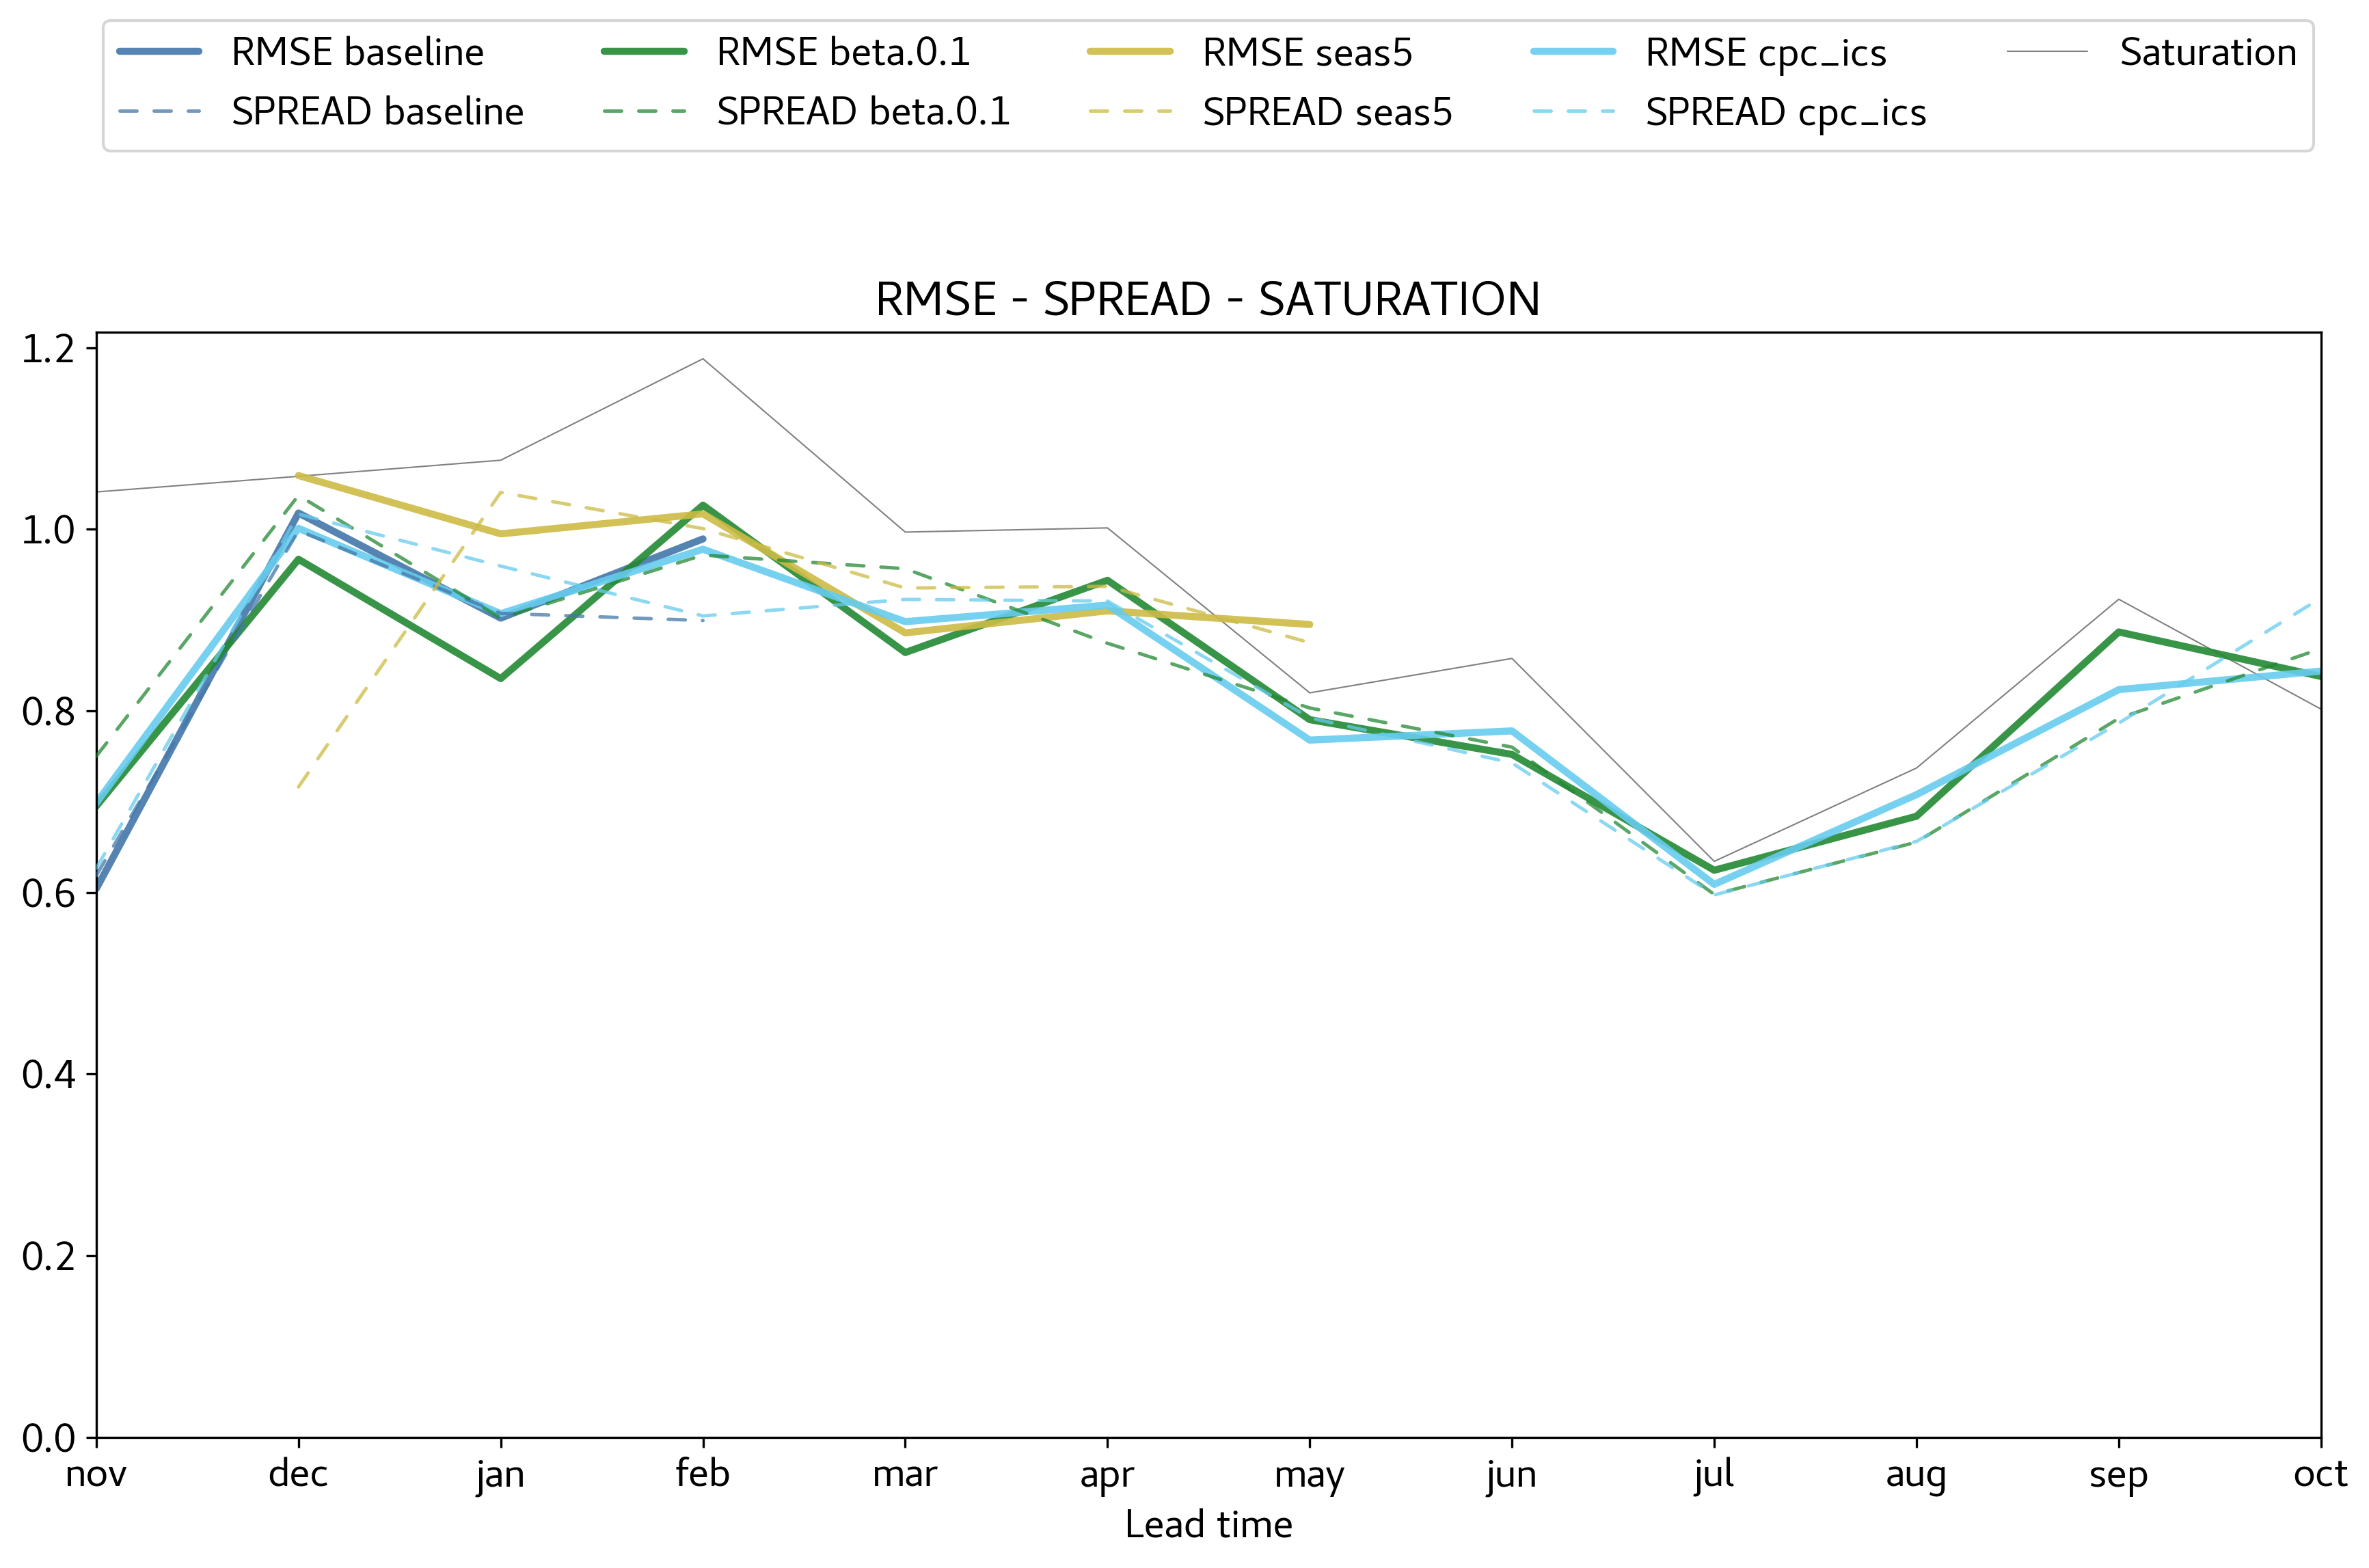

In [35]:
stats.plot_rmse_spread(rmses,
                       ufs_experiments,
                       rmse_only=False,
                       spread_only=False,
                       verif_stats=era5_stats,
                       title='RMSE - SPREAD - SATURATION',
                       dpi=300)